# Construction PPE Model Training and Export

This notebook demonstrates how to download, train, and export a YOLO model for construction site safety PPE detection using the Roboflow dataset.

You will:

- Check your environment and GPU availability
- Download the dataset from Roboflow
- Train a YOLO model using a modular DataModel class
- Save and export the trained model
- Visualize training results
- Run inference on a sample image

## Check GPU Availability

Ensure that a CUDA-capable GPU is available for training. If not, training will fall back to CPU (much slower).

In [4]:
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('Training will use CPU. Consider enabling GPU for faster training.')

CUDA available: True
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [5]:
# Import required libraries and DataModel class
from roboflow import Roboflow
from roboflow.core.project import Project
from roboflow.core.version import Version
from roboflow.core.dataset import Dataset
import os
from dotenv import load_dotenv
import json
from ultralytics import YOLO

# DataModel class definition (from train-ppe-data.py)
class DataModel:
    def __init__(self, project_name, version_number, dataset_path, model_dir, model_basename, model_weights="yolo11n.pt"):
        self.project_name = project_name
        self.version_number = version_number
        self.dataset_path = dataset_path
        os.makedirs(model_dir, exist_ok=True)
        self.model_dir = model_dir
        self.model_basename = model_basename
        self.model_weights = model_weights
        self.model = YOLO(self.model_weights)

    @property
    def model_path(self):
        return os.path.join(self.model_dir, f"{self.model_basename}.pt")

    @property
    def metadata_path(self):
        return os.path.join(self.model_dir, f"{self.model_basename}.json")

    @property
    def onnx_path(self):
        return os.path.join(self.model_dir, f"{self.model_basename}.onnx")

    def get_details(self):
        return {
            "project_name": self.project_name,
            "version_number": self.version_number,
            "dataset_path": self.dataset_path,
            "model_dir": self.model_dir,
            "model_basename": self.model_basename,
            "model_weights": self.model_weights,
        }

    def train(self, trainer=None, **kwargs):
        data_yaml = os.path.join(self.dataset_path, "data.yaml")
        kwargs["data"] = data_yaml
        metrics = self.model.train(trainer=trainer, **kwargs)
        print("Training complete.")
        return metrics

    def save(self, save_model=True, save_metadata=True, save_to=None):
        save_to = save_to or self.model_dir
        if save_model:
            model_path = os.path.join(save_to, f"{self.model_basename}.pt")
            os.makedirs(os.path.dirname(model_path), exist_ok=True)
            self.model.save(model_path)
            print(f"Model saved to {model_path}.")
        if save_metadata:
            metadata_path = os.path.join(save_to, f"{self.model_basename}.json")
            os.makedirs(os.path.dirname(metadata_path), exist_ok=True)
            with open(metadata_path, "w", encoding="utf-8") as f:
                json.dump(self.get_details(), f)
            print(f"Metadata saved to {metadata_path}.")

    def export(self, export_format="onnx", save_to=None, **kwargs):
        save_to = save_to or self.model_dir
        if export_format == "onnx":
            file_path = os.path.join(save_to, f"{self.model_basename}.onnx")
        else:
            file_path = os.path.join(save_to, f"{self.model_basename}.{export_format}")
        os.makedirs(os.path.dirname(file_path), exist_ok=True)
        self.model.export(format=export_format, **kwargs)
        print(f"Model exported to {file_path} in {export_format} format.")

# Load environment variables
load_dotenv()
ROBOFLOW_API_KEY = os.getenv("ROBOFLOW_API_KEY")
MODEL_DIR = os.getenv("MODEL_DIR", "Model")
MODEL_BASENAME = os.getenv("MODEL_BASENAME", "ibcm-ppe")

## Download Dataset, Train, Save, and Export Model

This cell downloads the dataset from Roboflow, trains a YOLO model, saves the model and metadata, and exports to ONNX.

In [6]:
# Acknowledge dataset source for compliance with CC BY 4.0 license
# Dataset: Construction Site Safety by Roboflow Universe Projects
# URL: https://universe.roboflow.com/roboflow-universe-projects/construction-site-safety
# License: CC BY 4.0

rf: Roboflow = Roboflow(api_key=ROBOFLOW_API_KEY)
project: Project = rf.workspace("roboflow-universe-projects").project("construction-site-safety")
version: Version = project.version(27)
dataset: Dataset = version.download("yolo11")

loading Roboflow workspace...
loading Roboflow project...

Version export complete for yolo11 format


In [9]:

data_model = DataModel(
    project_name=project.name,
    version_number=version.version,
    dataset_path=dataset.location,
    model_dir=MODEL_DIR,
    model_basename=MODEL_BASENAME,
    model_weights="yolo11n.pt",
)

In [10]:
TRAIN_PARAMS = {
    "epochs": 100,  # Reduce epochs for faster training
    "device": 'cuda' if torch.cuda.is_available() else 'cpu',  # Use GPU for faster training
    "imgsz": 640,  # Lower image size for faster training and less VRAM usage
    "workers": 8,  # Increase number of data loader workers for faster data loading
    "batch": 16,  # Try 24, reduce if you get out-of-memory errors
    "optimizer": "AdamW",  # Use AdamW optimizer for better convergence
    # "lr0": 0.001,  # Set an appropriate learning rate
    "augment": True,  # Enable data augmentation
    # "amp": torch.cuda.is_available(),  # Enable mixed precision for faster training and less memory usage
}

# Train and export the model using the modular method
data_model.train(**TRAIN_PARAMS)

New https://pypi.org/project/ultralytics/8.3.112 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.110  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: task=detect, mode=train, model=yolo11n.pt, data=c:\Users\tsrin\Projects\ibcm\backend\Construction-Site-Safety-27\data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=cuda, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=True, agnostic_nms=False, classes=None

train: Scanning C:\Users\tsrin\Projects\ibcm\backend\Construction-Site-Safety-27\train\labels.cache... 2603 images, 5 backgrounds, 0 corrupt: 100%|██████████| 2603/2603 [00:00<?, ?it/s]

train: WARNING  C:\Users\tsrin\Projects\ibcm\backend\Construction-Site-Safety-27\train\images\construction-855-_jpg.rf.723d19d48345a0cd8e3ab92a56c270e6.jpg: 1 duplicate labels removed
train: WARNING  C:\Users\tsrin\Projects\ibcm\backend\Construction-Site-Safety-27\train\images\mask-wearing-1632932085584_png_jpg.rf.960ad3dacd717d22e329aa5c790b1a1f.jpg: 1 duplicate labels removed
train: WARNING  C:\Users\tsrin\Projects\ibcm\backend\Construction-Site-Safety-27\train\images\n457047_jpg.rf.9fff0be5b2f8c422e37edabbe610a5b9.jpg: 1 duplicate labels removed
train: WARNING  C:\Users\tsrin\Projects\ibcm\backend\Construction-Site-Safety-27\train\images\youtube-42_jpg.rf.7f0f716dac24ac5a053a4bada1e00527.jpg: 1 duplicate labels removed


val: Fast image access  (ping: 0.60.2 ms, read: 33.510.5 MB/s, size: 52.1 KB)


val: Scanning C:\Users\tsrin\Projects\ibcm\backend\Construction-Site-Safety-27\valid\labels.cache... 114 images, 10 backgrounds, 0 corrupt: 100%|██████████| 114/114 [00:00<?, ?it/s]


...

                   all        114        697       0.89       0.63      0.728      0.414



100 epochs completed in 1.207 hours.
Optimizer stripped from runs\detect\train\weights\last.pt, 5.5MB
Optimizer stripped from runs\detect\train\weights\best.pt, 5.5MB

Validating runs\detect\train\weights\best.pt...
Ultralytics 8.3.110  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
YOLO11n summary (fused): 100 layers, 2,584,102 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:02<00:00,  1.62it/s]


                   all        114        697      0.843      0.677      0.738       0.42
               Hardhat         42         79      0.934       0.72      0.787      0.472
                  Mask         19         21          1      0.847      0.865      0.592
            NO-Hardhat         37         69      0.826      0.565      0.589       0.26
               NO-Mask         44         74      0.879      0.527       0.65        0.3
        NO-Safety Vest         56        106      0.823      0.613      0.692      0.376
                Person         84        166      0.825      0.708      0.772      0.442
           Safety Cone         13         44      0.898      0.864      0.876      0.469
           Safety Vest         28         41       0.81      0.732      0.778      0.473
             machinery         26         55      0.785      0.794      0.862      0.528
               vehicle         16         42      0.651      0.405      0.507       0.29
Speed: 0.2ms preproce

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000002C2A0798A50>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,   

In [21]:
data_model.save(save_to=MODEL_DIR)

Model saved to Model\ibcm-ppe.pt.
Metadata saved to Model\ibcm-ppe.json.


In [33]:
data_model.model.export(format="onnx", dynamic=True)

Ultralytics 8.3.110  Python-3.11.9 torch-2.5.1+cu121 CPU (12th Gen Intel Core(TM) i5-12450H)
YOLO11n summary (fused): 100 layers, 2,584,102 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from 'runs\detect\train\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 14, 8400) (5.2 MB)

ONNX: starting export with onnx 1.17.0 opset 19...
ONNX: slimming with onnxslim 0.1.50...
ONNX: export success  20.0s, saved as 'runs\detect\train\weights\best.onnx' (10.0 MB)

Export complete (20.5s)
Results saved to C:\Users\tsrin\Projects\ibcm\backend\runs\detect\train\weights
Predict:         yolo predict task=detect model=runs\detect\train\weights\best.onnx imgsz=640  
Validate:        yolo val task=detect model=runs\detect\train\weights\best.onnx imgsz=640 data=c:\Users\tsrin\Projects\ibcm\backend\Construction-Site-Safety-27\data.yaml  
Visualize:       https://netron.app


'runs\\detect\\train\\weights\\best.onnx'

## Visualize Training Results

If training was performed, visualize the results (loss curves, metrics, etc.).

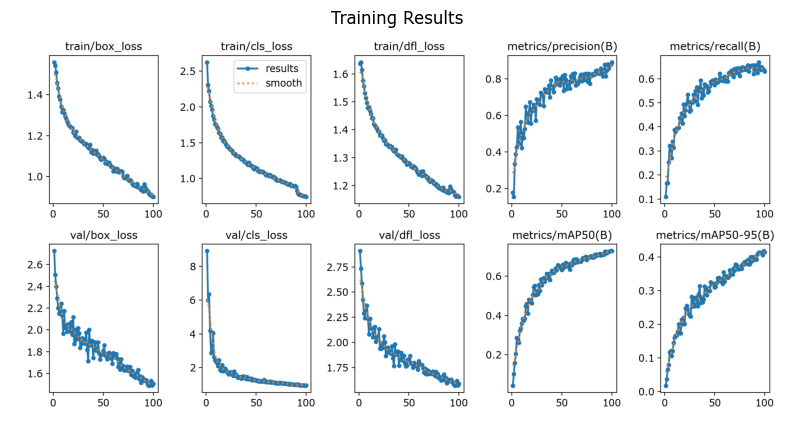

In [39]:
# Visualize training results if available
%matplotlib inline
import glob
import matplotlib.pyplot as plt
from PIL import Image

results_dir = os.path.join('runs', 'detect')
if os.path.exists(results_dir) and os.listdir(results_dir):  # Check if directory exists and is not empty
    run_dirs = sorted(glob.glob(os.path.join(results_dir, '*')), key=os.path.getmtime, reverse=True)
    if run_dirs:
        latest_run = run_dirs[0]
        results_png = os.path.join(latest_run, 'results.png')
        if os.path.exists(results_png):
            img = Image.open(results_png)
            plt.figure(figsize=(10, 6))
            plt.imshow(img)
            plt.axis('off')
            plt.title('Training Results')
            plt.show()
        else:
            print('No results.png found in latest run directory.')
    else:
        print('No run directories found in results.')
else:
    print(f"No training results directory found at {results_dir}. Ensure training has completed successfully.")

## Run Inference on a Sample Image

Test the trained model on a sample image from the validation set.


image 1/1 c:\Users\tsrin\Projects\ibcm\backend\Construction-Site-Safety-27\valid\images\2009_003991_jpg.rf.c4fadb57b5579062cd4db5463ec3ba74.jpg: 640x640 1 NO-Hardhat, 1 NO-Mask, 1 NO-Safety Vest, 2 Persons, 37.6ms
Speed: 4.8ms preprocess, 37.6ms inference, 3.5ms postprocess per image at shape (1, 3, 640, 640)
Class: NO-Safety Vest, Confidence: 0.83
Class: NO-Hardhat, Confidence: 0.79
Class: Person, Confidence: 0.70
Class: NO-Mask, Confidence: 0.61
Class: Person, Confidence: 0.30


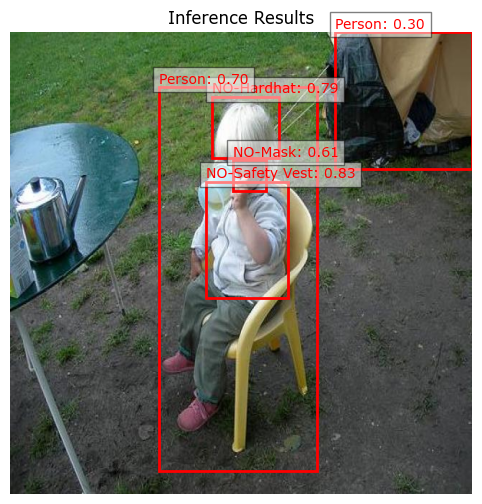

In [158]:
# Run inference on a sample image from the validation set and visualize results
import random
from typing import List
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics.engine.results import Results

val_images_dir = os.path.join(data_model.dataset_path or '', 'valid', 'images')
if os.path.exists(val_images_dir):
    images = [f for f in os.listdir(val_images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if images:
        sample_image = os.path.join(val_images_dir, random.choice(images))
        model: YOLO = YOLO(data_model.model_path)
        results: List[Results] = model(sample_image, save=False, show=False)
        # Print detected classes and their confidence scores
        for result in results[0].boxes.data:
            class_id = int(result[5].item())
            confidence = result[4].item()
            print(f"Class: {results[0].names[class_id]}, Confidence: {confidence:.2f}")
        

        # Visualize the results along with class and confidence
        img = Image.open(sample_image)
        plt.figure(figsize=(10, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.title('Inference Results')
        for box, result in zip(results[0].boxes.xyxy, results[0].boxes.data):  # Iterate over bounding boxes and results
            x1, y1, x2, y2 = box[:4].cpu().numpy()  # Move tensors to CPU and convert to NumPy
            class_id = int(result[5].item())
            confidence = result[4].item()
            label = f"{results[0].names[class_id]}: {confidence:.2f}"
            plt.gca().add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, edgecolor='red', facecolor='none', linewidth=2))
            plt.text(x1, y1 - 5, label, color='red', fontsize=10, bbox=dict(facecolor='white', alpha=0.5))
        plt.show()
    else:
        print('No images found in validation set.')
else:
    print('Validation images directory not found.')